# Tutorial 3 — Investment Study

## 1. Introduction to the study case

This tutorial explains how to handle **investment studies** in GEMS using the [GemsPy Python package](https://pypi.org/project/gemspy/).

We model a simple study case with:

- 1 **thermal plant** (with a capacity of 200 MW)
- 1 **renewable source** (time and scenario dependent)
- 1 **candidate thermal plant** (with a capacity to be assessed by the optimiser)
- 1 **load** (time and scenario dependent)

The optimiser finds the optimal capacity of the **candidate** plant to minimise total cost (investment + operational cost + unsupplied energy penalty).

### 1.1 Choice of the scenarios

We use **3 scenarios** and **4 timesteps**:

| Scenario | Load level | Renewable share | Without investment |
|---|---|---|---|
| **Scenario A** — Favourable | Low (55-70 MW) | High (5-60 MW) | No unsupplied energy |
| **Scenario B** — Critical | High (300-480 MW) | Low (5-20 MW) | 85-275 MW/h unsupplied energy |
| **Scenario C** — Intermediate | Medium (180-260 MW) | Medium (15-40 MW) | 0-45 MW/h unsupplied energy |


![Load](../../assets/tuto_invest_load_demand_plot.png)

![Renewable](../../assets/tuto_invest_renewable_generation_plot.png)

### 1.2 Study file structure

The study folder is inside the [`Tutorial_3_Investment/`](../Tutorial_3_Investment/Tutorial_Investment/ -TODO link to zip folder)

<details>
<summary><strong>Details of the <code>candidate_generator</code> model</strong></summary>

**parameters:**
- `investment_cost` — time and scenario independent, represents the initial investment cost
- `generation_cost` — time and scenario independent, represents the operational cost

**variables:**
- `p_installed` — the installed power capacity chosen by the optimiser; constant across time and scenarios, but *generation* will fluctuate
- `generation` — the actual power generation of the thermal candidate; cannot exceed `p_installed`

</details>

<details>
<summary><strong>⚠️ Warning — optim config file</strong></summary>

As we are running the study by GemsPy default **frontal** mode, we don't configure any `optim-config.yml` file.

Learn more about the GemsPy `optim-config.yml` file [in its documentation](https://gemspy.readthedocs.io/en/latest/user-guide/optim-config/).

</details>

## 2. Running the study
### 2.1 Installation of the required libraries

In [1]:
# Install required libraries
%pip install gemspy matplotlib --quiet --upgrade

Note: you may need to restart the kernel to use updated packages.


### 2.2 Load and solve the study

In [2]:
from pathlib import Path
from gems.study.folder import load_study
from gems.session.session import SimulationSession
from gems.optim_config.parsing import OptimConfig, TimeScopeConfig, ScenarioScopeConfig

_cwd = Path.cwd()
study_dir = _cwd / "Tutorial_Investment"

print("STUDY LOADING")
study = load_study(study_dir)
print("\tStudy loaded")

optim_config = OptimConfig(
    time_scope=TimeScopeConfig(first_time_step=0, last_time_step=167),
    scenario_scope=ScenarioScopeConfig(nb_scenarios=3),
)

print("\nSOLVING OPTIMIZATION PROBLEM")
result = SimulationSession(study=study, optim_config=optim_config).run()
print("\tOptimization problem solved")

STUDY LOADING
	Study loaded

SOLVING OPTIMIZATION PROBLEM


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'objective' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'expected_operating_cost' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
ERROR:   getOptionIndex: Option "solver_logs" is unknown
LP has 2526 rows; 3529 cols; 11094 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 1e+00]
  Cost    [3e-01, 3e+03]
  Bound   [4e+01, 2e+02]
  RHS     [5e-01, 5e+02]
Presolving model
2520 rows, 3526 cols, 11076 nonzeros 0s
1434 rows, 2866 cols, 4761 nonzeros 0s
1363 rows, 2464 cols, 4258 nonzeros 0s
Presolve reductions: rows 1363(-1163); columns 2464(-1065); nonzeros 4258(-6836) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
       1237     4.8894847826e+05 Pr: 0(0); Du: 0(6.4948e-15) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 1237
Objective value     :  4.8894847826e+05
P-D objective error :  2.9761623145e-16
HiGHS run time      :          0.03
	

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


## 3. Results Analysis

### 3.1 Constant output ; *p_installed*

Let's verify that the *p_installed* capacity is fit for tackling the load.

In the simulation-table, the amount this capacity is **275 MW** — equal to the highest net residual demand minus the existing thermal capacity (scenario 2, timestep 1: load 482 MW − renewable 7 MW − existing 200 MW = **275 MW**).

So, the *p_installed* optimised value is well suitable to our study.

### 3.2 Scenario/Time dependent outputs

As mentionned in the introduction, the result variables (`generation`, `unsupplied_energy`) are not constant. They fluctuate over the time and can differ across scenarios.

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.p

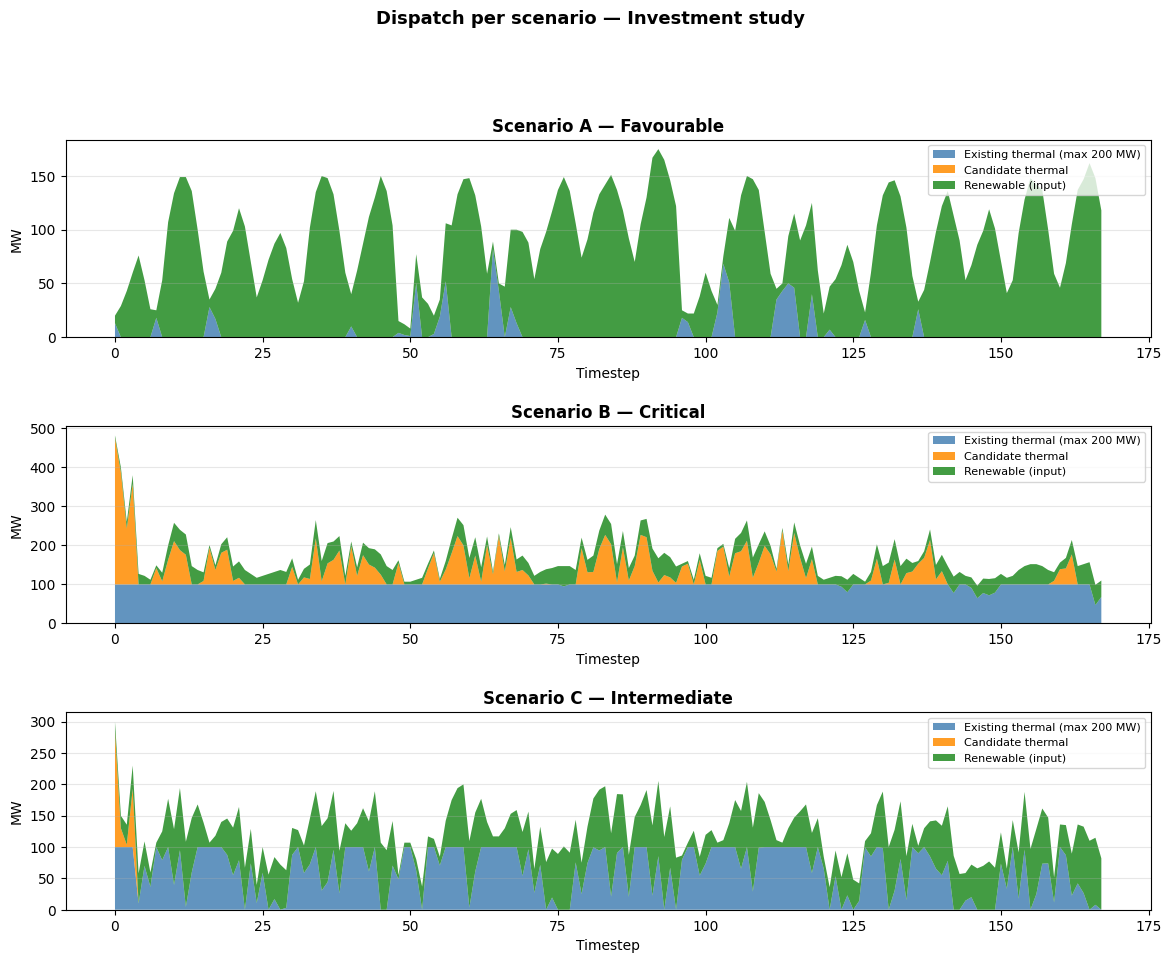

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, base64
from IPython.display import display

# Renewable generation is a parameter (input), not a variable — read from file directly
renewable_data = np.loadtxt(study_dir / "input/data-series/renewable_gen.txt")

scenario_labels = ["Scenario A — Favourable", "Scenario B — Critical", "Scenario C — Intermediate"]
timesteps = list(range(168))
colors = ["steelblue", "darkorange", "forestgreen"]
stack_labels = ["Existing thermal (max 200 MW)", "Candidate thermal", "Renewable (input)"]

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

for s, label in enumerate(scenario_labels):
    ax = fig.add_subplot(gs[s])

    existing_gen  = result.component("thermal_existing").output("generation").value(scenario_index=s).values
    candidate_gen = result.component("candidate_thermal").output("generation").value(scenario_index=s).values
    renewable_gen = renewable_data[timesteps, s]
    unsupplied    = result.component("node").output("unsupplied_energy").value(scenario_index=s).values

    ax.stackplot(timesteps, existing_gen, candidate_gen, renewable_gen,
                 labels=stack_labels, colors=colors, alpha=0.85)

    if any(u > 0.1 for u in unsupplied):
        ax.plot(timesteps, unsupplied, "rv--", linewidth=1.5, markersize=6, label="Unsupplied energy")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("MW")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Dispatch per scenario — Investment study", fontsize=13, fontweight="bold", y=1.01)

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
display(
    {"image/png": base64.b64encode(buf.read()).decode()},
    raw=True,
    metadata={"image/png": {"alt": "Stacked area charts showing dispatch (existing thermal, candidate thermal, renewable) for each of the 3 scenarios across 168 timesteps."}}
)
plt.close(fig)

### 3.3 Interpretation

Thanks to these plots, it's easy to get an overview of the behaviour of each scenario :
- Scenario A : As the scenario was already favourable (low load, renewable covers most of demand), the candidate thermal is never used by the optimiser.
- Scenario B : The combination of very high load and minimal renewable production forces the optimiser to set the thermal candidate's capacity to 275 MW. The worst case occurs at timestep 1 (load 482 MW, renewable only 7 MW), where both the existing 200 MW thermal and the full 275 MW candidate run at maximum.
- Scenario C : The intermediate scenario shows how the thermal candidate produces power only at its most demanding timestep (timestep 1: 44 MW), confirming it is the last resource dispatched due to its higher generation cost.